<a href="https://www.kaggle.com/code/fadhillahrandyw/lung-tb-cxr-classifier?scriptVersionId=336150763" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **LungTB_CXR_Classifier**

In [1]:
# loading libraries
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
ROOT_DIR = "/kaggle/input/datasets/fadhillahrandyw/combined-dataset/combined_cxr_dataset"  #
METADATA_CSV = os.path.join(ROOT_DIR, "/kaggle/input/datasets/fadhillahrandyw/combined-dataset/combined_cxr_dataset/combined_metadata.csv")

In [4]:
# preprocessing
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

In [5]:
#Custom Dataset reading from the metadata CSV
class CXRDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.label_to_idx = {"Normal": 0, "TB": 1}
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["label"], row["filename"])
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        label = self.label_to_idx[row["label"]]
        return image, label

In [6]:
# load metadata, split stratified by label+source 

def build_metadata(root_dir):
    records = []
    for label in ["Normal", "TB"]:
        folder = os.path.join(root_dir, label)
        for fname in os.listdir(folder):
            if not fname.lower().endswith(".png"):
                continue
            source = fname.split("_")[0]
            records.append({"filename": fname, "label": label, "source": source})
    return pd.DataFrame(records)
 
 
metadata = build_metadata(ROOT_DIR)
metadata["strata"] = metadata["label"] + "_" + metadata["source"]
 
train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata["strata"],
    random_state=SEED,
)
 
print("Train source distribution:")
print(train_df["source"].value_counts())
print("\nVal source distribution:")
print(val_df["source"].value_counts())
 
train_dataset = CXRDataset(train_df, ROOT_DIR, transform=transform)
val_dataset = CXRDataset(val_df, ROOT_DIR, transform=transform)
 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
 
print(f"\nTrain size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")

Train source distribution:
source
sairakiran    2406
nlm            640
belarus        238
dadb           223
Name: count, dtype: int64

Val source distribution:
source
sairakiran    602
nlm           160
belarus        60
dadb           55
Name: count, dtype: int64

Train size: 3507
Validation size: 877


In [7]:
# Class weights to handle TB:Normal imbalance

class_counts = train_df["label"].value_counts()
total = len(train_df)
weight_normal = total / (2 * class_counts["Normal"])
weight_tb = total / (2 * class_counts["TB"])
class_weights = torch.tensor([weight_normal, weight_tb], dtype=torch.float32)
print(f"\nClass weights [Normal, TB]: {class_weights.tolist()}")


Class weights [Normal, TB]: [2.0413272380828857, 0.6621978878974915]


In [8]:
#Model

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
class_weights = class_weights.to(device)
 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f"Device: {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


Device: cuda


In [9]:
#Training loop

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
 
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)
 
    print(f"\nEpoch {epoch + 1}")
    print(f"Training Loss: {avg_train_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")
 


Epoch 1
Training Loss: 0.2186
Validation Accuracy: 92.82%

Epoch 2
Training Loss: 0.1877
Validation Accuracy: 95.78%

Epoch 3
Training Loss: 0.1645
Validation Accuracy: 94.07%

Epoch 4
Training Loss: 0.1024
Validation Accuracy: 90.88%

Epoch 5
Training Loss: 0.1271
Validation Accuracy: 94.30%

Epoch 6
Training Loss: 0.0952
Validation Accuracy: 96.01%

Epoch 7
Training Loss: 0.0553
Validation Accuracy: 91.22%

Epoch 8
Training Loss: 0.0981
Validation Accuracy: 57.24%

Epoch 9
Training Loss: 0.1274
Validation Accuracy: 95.55%

Epoch 10
Training Loss: 0.0677
Validation Accuracy: 93.50%


In [10]:
# Save model

torch.save(model.state_dict(), "tb_model.pth")

In [11]:
# Confusion matrix, sensitivity, specificity

all_labels = []
all_predictions = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())
 
cm = confusion_matrix(all_labels, all_predictions)
print("\nConfusion matrix:")
print(cm)
 
TP, FN = cm[1, 1], cm[1, 0]
sensitivity = TP / (TP + FN)
print(f"Sensitivity: {sensitivity:.2%}")
 
TN, FP = cm[0, 0], cm[0, 1]
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.2%}")


Confusion matrix:
[[193  21]
 [ 36 627]]
Sensitivity: 94.57%
Specificity: 90.19%



AUC: 0.9781


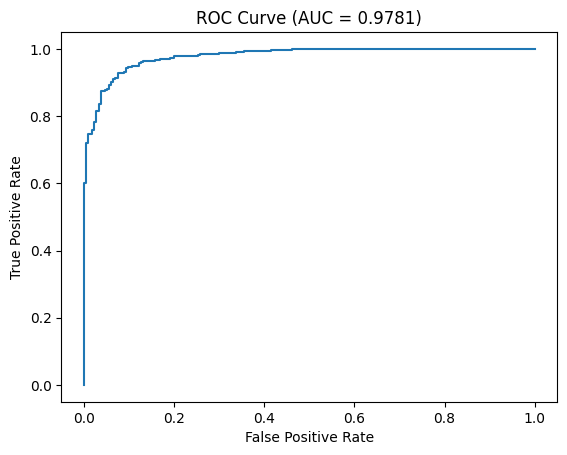

In [12]:
# AUC + ROC curve

all_labels = []
all_probs = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        tb_probs = probs[:, 1]
        all_probs.extend(tb_probs.cpu().numpy())
        all_labels.extend(labels.numpy())
 
auc = roc_auc_score(all_labels, all_probs)
print(f"\nAUC: {auc:.4f}")
 
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.4f})")
plt.show()